# 06 · Modelo de pronóstico a 24 h

**Objetivo:** pronosticar cloro, turbidez y pH de cada sensor 24 h adelante y evaluar contra la
meta del proyecto (`src/metas.py`):

> al menos el **80 %** de los pronósticos a 24 h dentro de la tolerancia en cloro (± 0,1 mg/L),
> turbidez (± 20 %, mínimo ± 0,2 UNT) y pH (± 0,1), en operación normal, **y mejor que el
> pronóstico ingenuo** "igual que ayer a la misma hora" en cada parámetro.

**Enfoque** (según lo aprendido en el EDA):

- **Un modelo por parámetro, compartido por los 21 sensores.** El sensor es una variable más, junto
  con su valor típico, porque el cloro normal cambia mucho de un sensor a otro (notebook 02).
- **Se pronostica el cambio, no el valor.** El modelo aprende cuánto se va a apartar el valor de
  dentro de 24 h del valor actual (que es la línea base). Solo tiene que aprender lo que la línea
  base no explica.
- **Variables de entrada** (`src/variables.py`): historia reciente del sensor (últimas 24 h), los
  demás parámetros del sensor, la fuente (J280) y la mediana de la red, porque los cambios de la
  fuente llegan con 1 a 16 h de retraso (notebook 03); hora del día y época del año; lluvia
  acumulada reciente y caudal de la fuente.
- **Algoritmo:** `HistGradientBoostingRegressor` de scikit-learn (árboles de decisión potenciados),
  con error absoluto como función de pérdida. La turbidez se modela en escala logarítmica.

**Uso de las particiones:** se entrena con entrenamiento (ene 2025 – abr 2026), se toman las
decisiones mirando validación (may – ago 2026) y la prueba (sep – dic 2026) se evalúa una sola vez al
final.

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.inspection import permutation_importance

from src import carga, calidad, metas, modelo, variables
from src.graficos import estilo, guardar, COLORES, GRIS

estilo()
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

t15 = calidad.lecturas_validas(carga.cargar_todo())
h = variables.horario(t15)
tabla, tipicos = variables.tabla(h, horizonte=metas.HORIZONTE_H)
X = variables.columnas_entrada(tabla)
PARAM = metas.PARAMETROS_META
ETIQ = {"CL2": "Cloro libre", "TURB": "Turbidez", "PH": "pH"}

entr = tabla["particion"] == "entrenamiento"
val = tabla["particion"] == "validacion"
prueba = tabla["particion"] == "prueba"
print(f"Tabla: {len(tabla):,} filas (sensor × hora) · {len(X)} variables de entrada")
print({p: int(m.sum()) for p, m in [("entrenamiento", entr), ("validación", val), ("prueba", prueba)]})

Tabla: 367,920 filas (sensor × hora) · 84 variables de entrada
{'entrenamiento': 244440, 'validación': 61992, 'prueba': 61488}


## 1. Entrenamiento

Un modelo por parámetro. `early_stopping` separa internamente un 10 % del entrenamiento para decidir
cuántos árboles usar, así que la validación no se toca para eso.

In [2]:
modelos, tiempos = {}, {}
for p in PARAM:
    t0 = time.time()
    modelos[p] = modelo.entrenar(tabla, p, X, entr)
    tiempos[p] = time.time() - t0
    print(f"{p}: {modelos[p].n_iter_} árboles · {tiempos[p]:.0f} s")

CL2: 400 árboles · 34 s


TURB: 400 árboles · 28 s


PH: 400 árboles · 29 s


## 2. Resultado en validación

Para cada parámetro: porcentaje de pronósticos dentro de la tolerancia (el criterio de la meta) y
error absoluto medio, del modelo y de la línea base, por separado en operación normal y durante
eventos (según si hay evento visible en el sensor a la hora pronosticada).

In [3]:
def evaluar(filas, pronosticos=None):
    resultados = []
    for p in PARAM:
        d = tabla[filas & tabla[f"objetivo_{p}"].notna() & tabla[p].notna()]
        obs = d[f"objetivo_{p}"].values
        pron = modelo.pronosticar(modelos[p], d, p, X) if pronosticos is None else pronosticos[p]
        base = d[p].values
        for cond, m in [("normal", d["evento_objetivo"].values == 0), ("evento", d["evento_objetivo"].values > 0)]:
            fila = {"parámetro": p, "condición": cond, "pronósticos": int(m.sum())}
            for nombre, x in [("modelo", pron), ("línea base", base)]:
                fila[f"% acierto {nombre}"] = 100 * np.nanmean(metas.acierto(p, obs[m], x[m]))
                fila[f"error medio {nombre}"] = np.nanmean(np.abs(obs[m] - x[m]))
            resultados.append(fila)
    r = pd.DataFrame(resultados).set_index(["parámetro", "condición"])
    r["mejora (puntos)"] = r["% acierto modelo"] - r["% acierto línea base"]
    return r[["pronósticos", "% acierto modelo", "% acierto línea base", "mejora (puntos)",
              "error medio modelo", "error medio línea base"]]

def cumple(r):
    n = r.xs("normal", level="condición")
    return pd.DataFrame({
        "% acierto (normal)": n["% acierto modelo"],
        "≥ 80 %": n["% acierto modelo"] >= metas.META_PCT,
        "mejor que la línea base": n["% acierto modelo"] > n["% acierto línea base"],
        "cumple la meta": (n["% acierto modelo"] >= metas.META_PCT) & (n["% acierto modelo"] > n["% acierto línea base"]),
    })

res_val = evaluar(val)
res_val

pronósticos  % acierto modelo  % acierto línea base  mejora (puntos)  error medio modelo  error medio línea base
parámetro condición                                                                                                                  
CL2       normal           58223            86.809                75.355           11.454               0.053                   0.085
          evento            3416            20.580                19.877            0.703               0.355                   0.348
TURB      normal           58253            52.263                52.002            0.261               0.275                   0.362
          evento            3416            47.190                58.372          -11.183               0.456                   0.469
PH        normal           58211            82.349                80.158            2.190               0.061                   0.068
          evento            3416            64.256                68.648           -4.391               0.194                   0.194

In [4]:
cumple(res_val)

,% acierto (normal),≥ 80 %,mejor que la línea base,cumple la meta
parámetro,,,,
CL2,86.809,True,True,True
TURB,52.263,False,True,False
PH,82.349,True,True,True


### Por sensor y por mes

¿El modelo funciona parejo en toda la red y en todo el periodo, o hay sensores o meses donde falla?

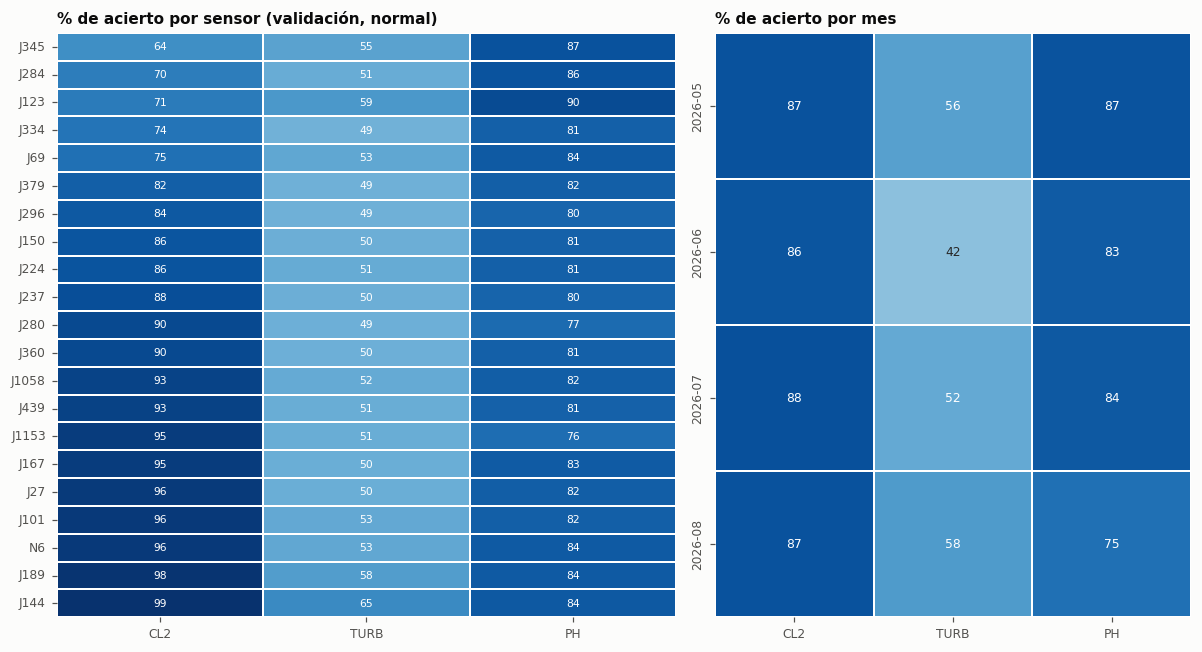

In [5]:
d = tabla[val & (tabla["evento_objetivo"] == 0)].copy()
for p in PARAM:
    ok = d[f"objetivo_{p}"].notna() & d[p].notna()
    d[f"ok_{p}"] = np.nan
    d.loc[ok, f"ok_{p}"] = metas.acierto(p, d.loc[ok, f"objetivo_{p}"], modelo.pronosticar(modelos[p], d[ok], p, X))
    d[f"base_{p}"] = metas.acierto(p, d[f"objetivo_{p}"], d[p])

por_sensor = d.groupby("nodo")[[f"ok_{p}" for p in PARAM]].mean().mul(100)
por_sensor.columns = PARAM
por_sensor = por_sensor.sort_values("CL2")
d["mes"] = d["fecha"].dt.strftime("%Y-%m")
por_mes = d.groupby("mes")[[f"ok_{p}" for p in PARAM]].mean().mul(100)
por_mes.columns = PARAM

fig, axes = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={"width_ratios": [1.3, 1]})
sns.heatmap(por_sensor, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=axes[0],
            linewidths=1, linecolor="white", annot_kws={"fontsize": 7})
axes[0].set_title("% de acierto por sensor (validación, normal)", fontsize=10); axes[0].set_ylabel("")
sns.heatmap(por_mes, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=axes[1],
            linewidths=1, linecolor="white", annot_kws={"fontsize": 8})
axes[1].set_title("% de acierto por mes", fontsize=10); axes[1].set_ylabel("")
for ax in axes:
    ax.grid(False)
fig.tight_layout()
guardar(fig, "06_acierto_sensor_mes"); plt.show()

### Un ejemplo

Pronóstico a 24 h contra lo observado en un sensor intermedio (J224) durante dos semanas de
validación. La línea punteada es la línea base: el valor de 24 h antes. Cada punto del pronóstico se hizo 24 h antes, con la información disponible en ese
momento.

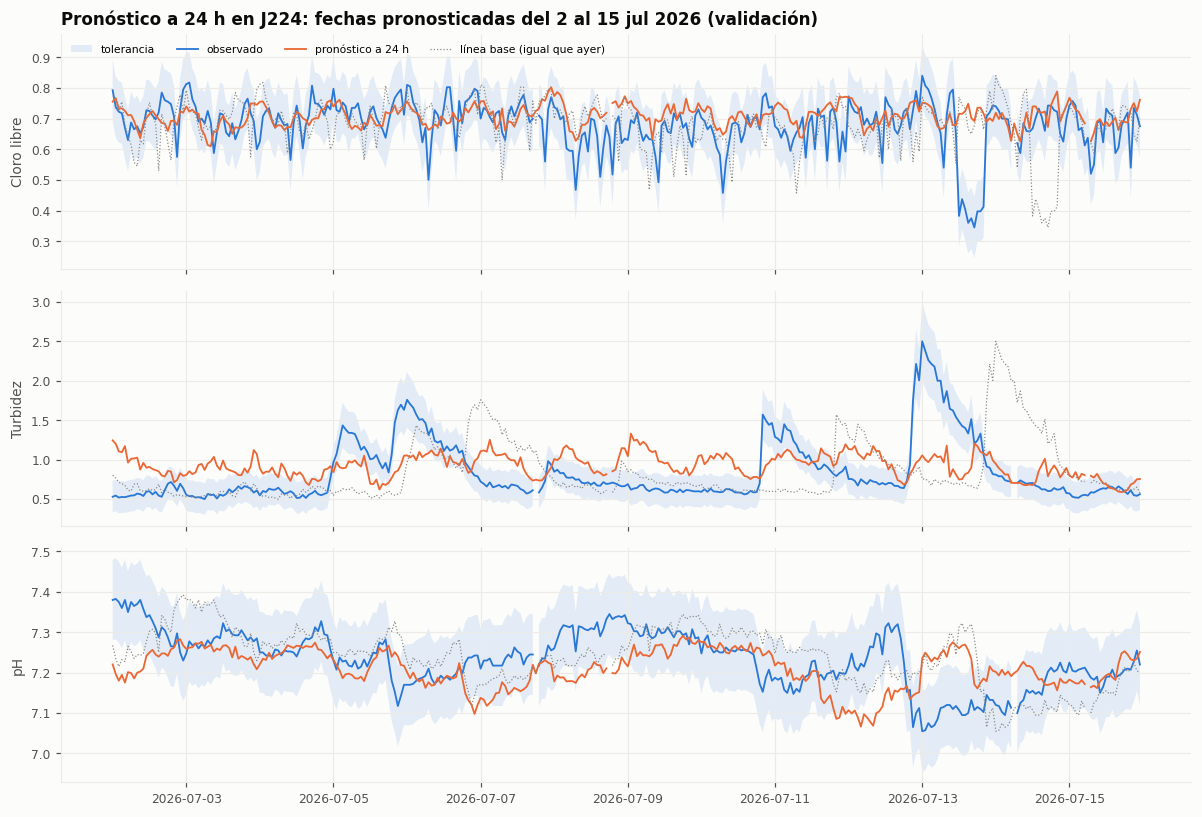

In [6]:
n_ej = "J224"
ej = tabla[val & (tabla["nodo"] == n_ej)].set_index("fecha")
ventana = ej.loc["2026-07-01":"2026-07-14"]
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
for ax, p in zip(axes, PARAM):
    fechas_obj = ventana.index + pd.Timedelta(hours=24)
    obs = ventana[f"objetivo_{p}"].values
    pron = modelo.pronosticar(modelos[p], ventana.reset_index(), p, X)
    tol = metas.tolerancia(p, obs)
    ax.fill_between(fechas_obj, obs - tol, obs + tol, color=COLORES[0], alpha=0.12, lw=0, label="tolerancia")
    ax.plot(fechas_obj, obs, color=COLORES[0], lw=1.2, label="observado")
    ax.plot(fechas_obj, pron, color=COLORES[1], lw=1.2, label="pronóstico a 24 h")
    ax.plot(fechas_obj, ventana[p].values, color=GRIS, lw=0.8, ls=":", label="línea base (igual que ayer)")
    ax.set_ylabel(f"{ETIQ[p]}")
axes[0].legend(ncol=4, fontsize=7, loc="upper left")
axes[0].set_title(f"Pronóstico a 24 h en {n_ej}: fechas pronosticadas del 2 al 15 jul 2026 (validación)")
fig.tight_layout()
guardar(fig, "06_ejemplo_pronostico"); plt.show()

## 3. ¿Qué variables usa el modelo?

Importancia por permutación en una muestra de validación: cuánto empeora el error si se desordena
cada variable. Se muestran las 12 más importantes de cada modelo.

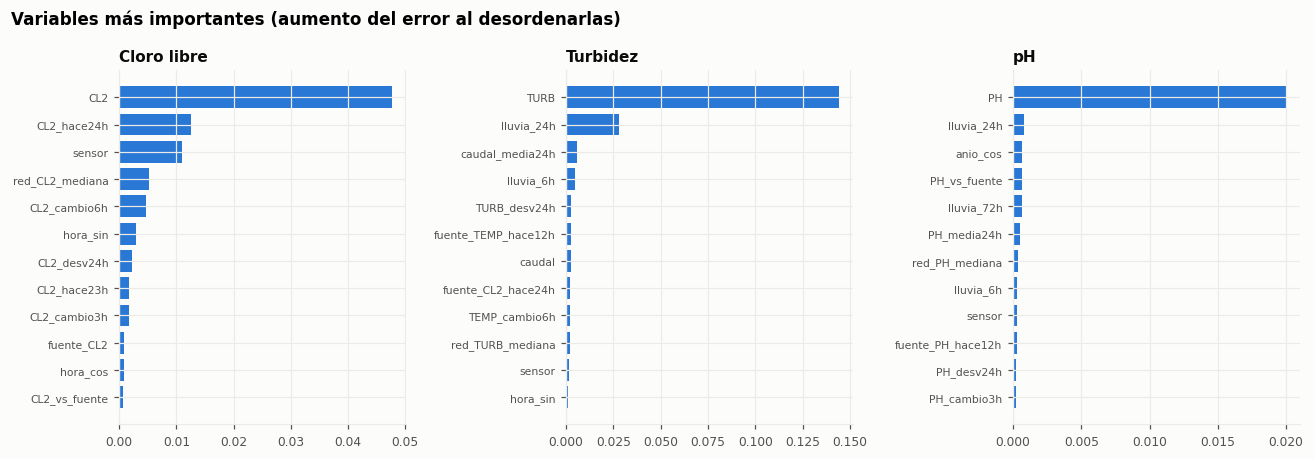

In [7]:
muestra = tabla[val].sample(15000, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
importancias = {}
for ax, p in zip(axes, PARAM):
    m = muestra[f"objetivo_{p}"].notna() & muestra[p].notna()
    r = permutation_importance(modelos[p], muestra.loc[m, X], modelo.objetivo(muestra[m], p),
                               n_repeats=3, random_state=0, scoring="neg_mean_absolute_error")
    imp = pd.Series(r.importances_mean, index=X).sort_values(ascending=False).head(12)
    importancias[p] = imp
    ax.barh(imp.index[::-1], imp.values[::-1], color=COLORES[0])
    ax.set_title(ETIQ[p], fontsize=10)
    ax.tick_params(axis="y", labelsize=7)
fig.suptitle("Variables más importantes (aumento del error al desordenarlas)", x=0.01, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
guardar(fig, "06_importancia_variables"); plt.show()

## 4. Experimento: turbidez con un pronóstico de lluvia perfecto

La turbidez es lo único que el modelo no logra pronosticar mejor que la línea base. Según el EDA, a
24 h depende de lluvia que todavía no ha caído. Para medir cuánto aportaría un pronóstico de lluvia,
se repite el modelo agregando la **lluvia real de las 6, 12 y 24 h siguientes**, como si el
pronóstico fuera perfecto.

Esto **no** es un modelo utilizable: en operación esa información no existe. Es una **cota
superior**: lo máximo que podría aportar el clima. Con pronósticos reales (que se equivocan) y con
los datos del IMN, la mejora será menor.

In [8]:
lluvia = h["lluvia_mm"]
futura = pd.DataFrame({f"lluvia_prox{k}h": lluvia[::-1].rolling(k, min_periods=1).sum()[::-1].shift(-1)
                       for k in [6, 12, 24]})
tabla_exp = tabla.merge(futura, left_on="fecha", right_index=True, how="left")
X_exp = X + list(futura.columns)
mod_exp = modelo.entrenar(tabla_exp, "TURB", X_exp, entr)

d = tabla_exp[val & tabla_exp["objetivo_TURB"].notna() & tabla_exp["TURB"].notna()]
obs = d["objetivo_TURB"].values
normal_ = d["evento_objetivo"].values == 0
comp = {}
for nombre, pron in [("línea base", d["TURB"].values),
                     ("modelo (sin lluvia futura)", modelo.pronosticar(modelos["TURB"], d, "TURB", X)),
                     ("modelo + lluvia futura perfecta", modelo.pronosticar(mod_exp, d, "TURB", X_exp))]:
    ok = metas.acierto("TURB", obs, pron)
    comp[nombre] = {"% acierto normal": 100 * np.nanmean(ok[normal_]), "% acierto eventos": 100 * np.nanmean(ok[~normal_])}
pd.DataFrame(comp).T

,% acierto normal,% acierto eventos
línea base,52.002,58.372
modelo (sin lluvia futura),52.263,47.190
modelo + lluvia futura perfecta,88.629,87.295


## 5. Evaluación final en el periodo de prueba

Se evalúa una sola vez, con los modelos ya fijados. Es el resultado que se reporta.

In [9]:
res_prueba = evaluar(prueba)
res_prueba

pronósticos  % acierto modelo  % acierto línea base  mejora (puntos)  error medio modelo  error medio línea base
parámetro condición                                                                                                                  
CL2       normal           55946            86.058                78.365            7.693               0.054                   0.074
          evento            4345            56.410                54.614            1.795               0.187                   0.189
TURB      normal           56174            62.160                55.344            6.816               0.255                   0.457
          evento            4360            43.165                37.156            6.009               2.597                   3.155
PH        normal           56195            87.225                84.415            2.810               0.053                   0.066
          evento            4381            65.305                67.998           -2.693               0.206                   0.205

In [10]:
final = cumple(res_prueba)
final

,% acierto (normal),≥ 80 %,mejor que la línea base,cumple la meta
parámetro,,,,
CL2,86.058,True,True,True
TURB,62.160,False,True,False
PH,87.225,True,True,True


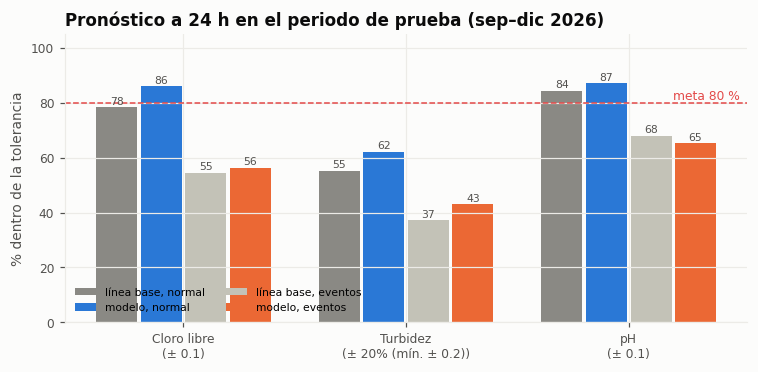

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
n = res_prueba.xs("normal", level="condición")
e = res_prueba.xs("evento", level="condición")
x = np.arange(len(PARAM))
ancho = 0.2
for k, (nombre, serie, color) in enumerate([("línea base, normal", n["% acierto línea base"], GRIS),
                                            ("modelo, normal", n["% acierto modelo"], COLORES[0]),
                                            ("línea base, eventos", e["% acierto línea base"], "#c3c2b7"),
                                            ("modelo, eventos", e["% acierto modelo"], COLORES[1])]):
    barras = ax.bar(x + (k - 1.5) * ancho, serie.values, ancho * 0.92, color=color, label=nombre)
    for b_, v_ in zip(barras, serie.values):
        ax.text(b_.get_x() + b_.get_width() / 2, v_ + 1, f"{v_:.0f}", ha="center", fontsize=7, color="#52514e")
ax.axhline(metas.META_PCT, color=COLORES[7], ls="--", lw=1)
ax.text(len(PARAM) - 0.5, metas.META_PCT + 1, "meta 80 %", color=COLORES[7], fontsize=8, ha="right")
ax.set_xticks(x); ax.set_xticklabels([f"{ETIQ[p]}\n({metas.texto_tolerancia(p)})" for p in PARAM])
ax.set_ylim(0, 105); ax.set_ylabel("% dentro de la tolerancia")
ax.set_title("Pronóstico a 24 h en el periodo de prueba (sep–dic 2026)")
ax.legend(ncol=2, fontsize=7, loc="lower left")
guardar(fig, "06_resultado_prueba"); plt.show()

## 6. Guardar los modelos

Se guardan en `modelos/` junto con lo necesario para usarlos después (por ejemplo, desde el panel):
las columnas de entrada y el valor típico de cada sensor.

In [12]:
carpeta = Path.cwd().parent / "modelos"
carpeta.mkdir(exist_ok=True)
joblib.dump({"modelos": modelos, "columnas": X, "tipicos": tipicos, "horizonte_h": metas.HORIZONTE_H,
             "sensores": sorted(tabla["nodo"].unique(), key=list(tabla["nodo"].unique()).index)},
            carpeta / "pronostico_24h.joblib", compress=3)
print("Guardado:", carpeta / "pronostico_24h.joblib",
      f"({(carpeta / 'pronostico_24h.joblib').stat().st_size / 1e6:.1f} MB)")

Guardado: /tmp/claude-0/prueba/Modelo_calidad_agua/modelos/pronostico_24h.joblib (2.2 MB)


## 7. Conclusiones

**Resultado en el periodo de prueba (sep–dic 2026)**

| Parámetro | Acierto del modelo (normal) | Línea base | ¿Cumple la meta? |
|---|---|---|---|
| Cloro libre (± 0,1 mg/L) | **86 %** | 78 % | **Sí** |
| pH (± 0,1) | **87 %** | 84 % | **Sí** |
| Turbidez (± 20 %, mín. 0,2 UNT) | **62 %** | 55 % | No: mejora la línea base, pero no llega al 80 % |

**Lo que muestra el modelo**

1. **El cloro es donde más aporta.** Sube del 78 % al 86 % y baja el error medio de 0,074 a
   0,054 mg/L. Usa sobre todo el valor actual, el de hace 24 h (ciclo diario), el sensor y la
   mediana de la red.
2. **El pH cumple, con una mejora pequeña.** De 84 % a 87 %. El pH casi no cambia en operación
   normal, así que la línea base ya es buena.
3. **La turbidez no llega con la información que hay hoy.** El modelo mejora la línea base (de 55 %
   a 62 % en prueba), pero en validación queda prácticamente empatado (52 % contra 52 %). La causa
   se vio en el EDA: a 24 h la turbidez depende de lluvia que todavía no ha caído.
4. **Con pronóstico de lluvia, la turbidez sí podría llegar.** En el experimento con lluvia futura
   perfecta, la turbidez sube a **89 %** en validación (y a 87 % en eventos). Es una cota superior:
   con pronósticos reales, que se equivocan, y con los datos del IMN la mejora será menor, pero
   muestra que el pronóstico del clima es justamente la pieza que falta.
5. **Durante eventos el modelo casi no mejora la línea base.** Cloro 56 % contra 55 %, y en pH queda
   un poco por debajo. Un pronóstico a 24 h no puede anticipar un evento que empieza de repente
   (una contaminación o una falla de la cloración); eso le toca al detector de eventos, no al
   pronóstico.
6. **Hay sensores más difíciles.** En cloro, J345, J284 y J123 quedan entre 64 % y 71 % en
   validación, contra más de 90 % en la mayoría. Son sensores con más eventos y más variación de
   un día a otro.

**Siguientes pasos**

- **Turbidez:** agregar al modelo el pronóstico de lluvia de las próximas 24 h. Para entrenar, los
  pronósticos pasados de Open-Meteo en las mismas fechas, que tienen errores reales; en vivo, el
  pronóstico actual. Se hace cuando lleguen los datos del IMN y se regenere el dataset.
- **Eventos:** un detector aparte, con las variables que salieron del notebook 05 (cuántos
  parámetros y sensores se desvían a la vez).
- **Sensores difíciles:** revisar si conviene un ajuste específico o más historia como entrada.